In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load your CSV file
df = pd.read_csv("Bank of England Database.csv")

# Preview
df.head()

,Date,Bank Rate
0,2000-01-01,5.50
1,2000-02-01,5.75
2,2000-03-01,6.00
3,2000-04-01,6.00
4,2000-05-01,6.00


In [4]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Handle missing values
df = df.dropna()

# Extract useful time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Optional: create lag features (important for time series ML)
df['Rate_Lag1'] = df['Bank Rate'].shift(1)
df['Rate_Lag2'] = df['Bank Rate'].shift(2)

df = df.dropna()


In [5]:
X = df[['Year', 'Month', 'Day', 'Rate_Lag1', 'Rate_Lag2']]
y = df['Bank Rate']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # important for time series
)

In [9]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("Decision Tree R²:", r2_score(y_test, y_pred_dt))

Decision Tree RMSE: 0.15811388300841897
Decision Tree R²: -0.6666666666666667


In [10]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Random Forest RMSE: 0.21969439000575322
Random Forest R²: -2.217708333333334


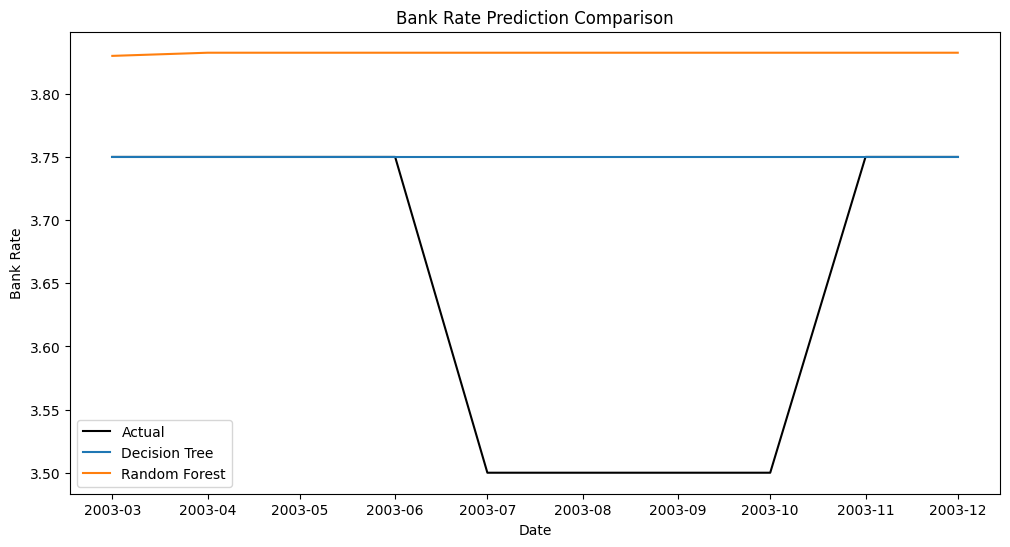

In [11]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'].iloc[-len(y_test):], y_test, label='Actual', color='black')
plt.plot(df['Date'].iloc[-len(y_test):], y_pred_dt, label='Decision Tree')
plt.plot(df['Date'].iloc[-len(y_test):], y_pred_rf, label='Random Forest')

plt.legend()
plt.title("Bank Rate Prediction Comparison")
plt.xlabel("Date")
plt.ylabel("Bank Rate")
plt.show()

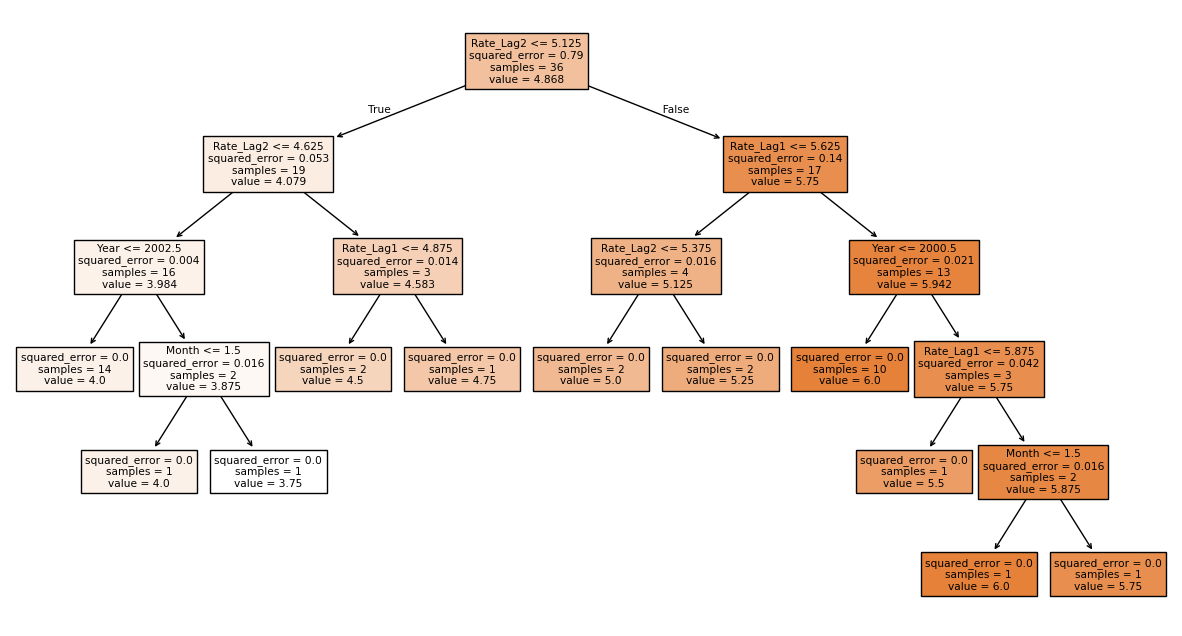

In [12]:
plt.figure(figsize=(15,8))
plot_tree(dt_model, feature_names=X.columns, filled=True)
plt.show()

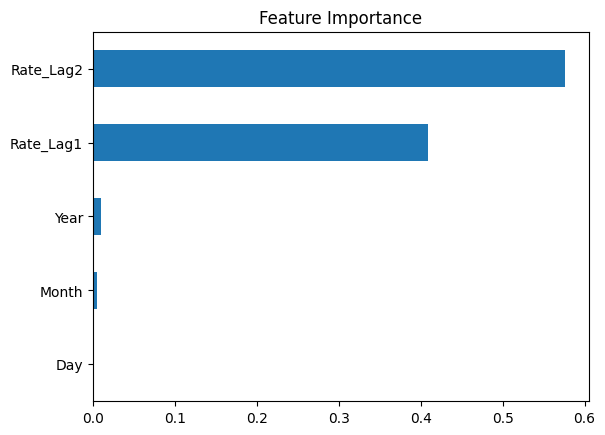

In [13]:
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values()

feat_imp.plot(kind='barh', title='Feature Importance')
plt.show()